# Open-World Fraud Detection
## Isolation Forest (Gate 1) + Random Forest (Gate 2)

**Pipeline:**
- Gate 1 — Isolation Forest - catches unknown fraud patterns
- Gate 2 — Random Forest - classifies known fraud vs normal

**Metrics:**
- KCA — Known Classification Accuracy
- URA — Unknown Rejection Accuracy
- OWRA — Open-World Recognition Accuracy (combined)

## Step 1 — Install & Import Libraries

In [20]:
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


Step 2 — Load Dataset

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
df = pd.read_csv('/content/drive/MyDrive/Minor-2/creditcard.csv')

In [23]:
print(df.head())
print(df['Class'].value_counts())  # Check imbalance

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [24]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

# Class distribution
class_counts = df['Class'].value_counts()
total = len(df)

print("\nClass Distribution:")
print(f"Non-Fraud (0): {class_counts[0]} ({class_counts[0]/total*100:.2f}%)")
print(f"Fraud (1): {class_counts[1]} ({class_counts[1]/total*100:.4f}%)")

# Preview data
df.head()

Shape: (284807, 31)
Missing values: 0

Class Distribution:
Non-Fraud (0): 284315 (99.83%)
Fraud (1): 492 (0.1727%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Step 3 — Preprocess Data

In [25]:
from sklearn.preprocessing import StandardScaler

# Scale only important numerical features
scaler = StandardScaler()
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

# Features (X) and Target (y)
X = df.drop('Class', axis=1).values
y = df['Class'].values

print("Total features:", X.shape[1])
print("Fraud cases:", (y == 1).sum())
print("Non-Fraud cases:", (y == 0).sum())

Total features: 30
Fraud cases: 492
Non-Fraud cases: 284315


Step 4 — Visualise Class Imbalance

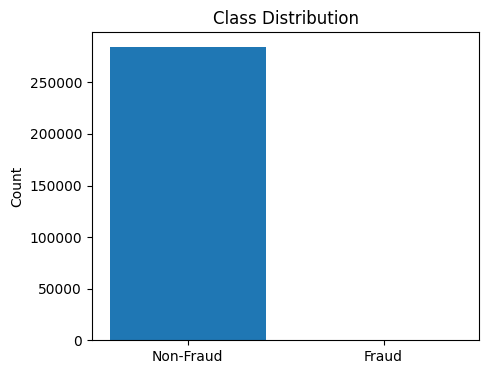

In [26]:
import matplotlib.pyplot as plt

counts = df['Class'].value_counts()

plt.figure(figsize=(5,4))
plt.bar(['Non-Fraud', 'Fraud'], counts.values)

plt.title('Class Distribution')
plt.ylabel('Count')

plt.show()

## Step 5 — Prepare Training Data for Isolation Forest

Isolation Forest is trained **only on normal transactions**.
It learns what normal looks like — anything that deviates is flagged as anomalous (potential unknown fraud).

In [27]:
from sklearn.model_selection import train_test_split

# Use only normal transactions
X_normal = X[y == 0]

# Split data for Isolation Forest
X_if_train, X_if_val = train_test_split(
    X_normal, test_size=0.1, random_state=42
)

print("Train samples:", X_if_train.shape[0])
print("Validation samples:", X_if_val.shape[0])

Train samples: 255883
Validation samples: 28432


## Step 6 — Train Isolation Forest (Gate 1)

- `n_estimators=300` — more trees = more stable scores
- `contamination='auto'` — lets IF decide its own boundary
- Threshold set at **2nd percentile** of normal scores
  - Scores below threshold → flagged as unknown/anomalous

In [28]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
)
iso_forest.fit(X_if_train)

# Set threshold (2nd percentile)
scores = iso_forest.score_samples(X_if_train)
if_threshold = np.percentile(scores, 2)

print("IF Threshold:", round(if_threshold, 4))

# Validation check
val_scores = iso_forest.score_samples(X_if_val)
anomaly_pct = (val_scores < if_threshold).mean() * 100

print("Validation anomalies (%):", round(anomaly_pct, 2))

IF Threshold: -0.5393
Validation anomalies (%): 1.94


## Step 7 — Prepare Training Data for Random Forest

- Uses normal + **known** fraud transactions
- SMOTE balances the extreme class imbalance before training

In [29]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split data
X_tr, X_val_rf, y_tr, y_val_rf = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

print("Before SMOTE:",
      "Non-Fraud =", (y_tr == 0).sum(),
      "Fraud =", (y_tr == 1).sum())

# Apply SMOTE (only on training data)
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

print("After SMOTE:",
      "Non-Fraud =", (y_tr_sm == 0).sum(),
      "Fraud =", (y_tr_sm == 1).sum())

Before SMOTE: Non-Fraud = 241667 Fraud = 418
After SMOTE: Non-Fraud = 241667 Fraud = 241667


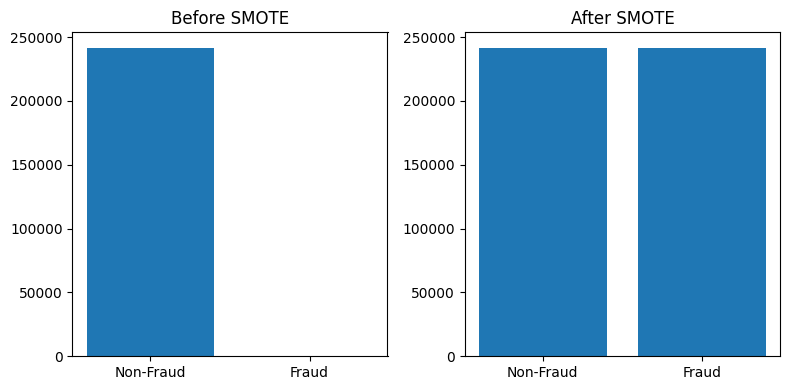

In [30]:
import matplotlib.pyplot as plt

before = [sum(y_tr == 0), sum(y_tr == 1)]
after  = [sum(y_tr_sm == 0), sum(y_tr_sm == 1)]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.bar(['Non-Fraud','Fraud'], before)
plt.title("Before SMOTE")

plt.subplot(1,2,2)
plt.bar(['Non-Fraud','Fraud'], after)
plt.title("After SMOTE")

plt.tight_layout()
plt.show()

## Step 8 — Train Random Forest (Gate 2)

- `n_estimators=100` — 100 decision trees
- `class_weight='balanced'` — extra protection on top of SMOTE
- `max_features='sqrt'` — standard for RF classification

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=50,        # reduce trees
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_tr_sm, y_tr_sm)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
                       random_state=42)

Step 9 — Two-Stage Fraud Detection (Isolation Forest + Random Forest)

A transaction first passes through Isolation Forest (Gate 1)

- If it is detected as an anomaly → it is REJECTED as UNKNOWN fraud
- If it is normal → it moves to the next stage

The transaction then goes to Random Forest (Gate 2)

- If classified as fraud → it is BLOCKED (known fraud)
- If classified as normal → it is ALLOWED


In [33]:
def two_stage_inference(X):

    # Gate 1: Isolation Forest
    if_scores = iso_forest.score_samples(X)
    is_unknown = if_scores < if_threshold

    # Gate 2: Random Forest
    rf_probs = rf_model.predict_proba(X)[:, 1]
    is_fraud = rf_probs >= 0.5

    # Final decision
    final = np.where(
        is_unknown, "REJECT_UNKNOWN",
        np.where(is_fraud, "BLOCK", "ALLOW")
    )

    return final

Step 10 — Open-World Evaluation (KCA, URA, OWRA)
- KCA: Accuracy on known data
- URA: Rejection of unknown fraud
- OWRA: Overall performance

In [36]:
def open_world_test(unknown_fraction):

    print(f"\n--- {int(unknown_fraction*100)}% Unknown Fraud ---")

    # Split fraud into known & unknown
    fraud_idx = np.where(y == 1)[0]
    np.random.shuffle(fraud_idx)

    split = int(len(fraud_idx) * (1 - unknown_fraction))
    known_idx = fraud_idx[:split]
    unknown_idx = fraud_idx[split:]

    normal_idx = np.where(y == 0)[0]

    # Known data (normal + known fraud)
    X_known = np.vstack([X[normal_idx], X[known_idx]])
    y_known = np.hstack([np.zeros(len(normal_idx)), np.ones(len(known_idx))])

    # Unknown fraud
    X_unknown = X[unknown_idx]

    # Predictions
    known_preds = two_stage_inference(X_known)
    unknown_preds = two_stage_inference(X_unknown)

    # KCA
    kca = (
        (known_preds[y_known == 0] == "ALLOW").mean() +
        (known_preds[y_known == 1] == "BLOCK").mean()
    ) / 2

    # URA
    ura = (unknown_preds == "REJECT_UNKNOWN").mean()

    # OWRA
    total_correct = (
        (known_preds[y_known == 0] == "ALLOW").sum() +
        (known_preds[y_known == 1] == "BLOCK").sum() +
        (unknown_preds == "REJECT_UNKNOWN").sum()
    )
    total = len(known_preds) + len(unknown_preds)
    owra = total_correct / total

    print(f"KCA: {kca:.3f}, URA: {ura:.3f}, OWRA: {owra:.3f}")

Step 11 — Run Open-World Experiment (25% Unknown Fraud)

In [37]:
# Run experiment for 25% unknown fraud
open_world_test(0.25)


--- 25% Unknown Fraud ---
KCA: 0.606, URA: 0.715, OWRA: 0.978


Run Open-World Experiment (50% Unknown Fraud)

In [38]:
# Run experiment for 50% unknown fraud
open_world_test(0.50)


--- 50% Unknown Fraud ---
KCA: 0.601, URA: 0.715, OWRA: 0.978


In [39]:
# Run experiment for 75% unknown fraud
open_world_test(0.75)


--- 75% Unknown Fraud ---
KCA: 0.583, URA: 0.710, OWRA: 0.978


Step 12  — Summary of Open-World Experiments

In [40]:

results = []

for u in [0.25, 0.50, 0.75]:
    print("\nRunning for:", u)
    open_world_test(u)


Running for: 0.25

--- 25% Unknown Fraud ---
KCA: 0.607, URA: 0.732, OWRA: 0.978

Running for: 0.5

--- 50% Unknown Fraud ---
KCA: 0.599, URA: 0.724, OWRA: 0.978

Running for: 0.75

--- 75% Unknown Fraud ---
KCA: 0.607, URA: 0.726, OWRA: 0.978
